#Section 1 — Setup and Dataset Loading

# Review Sentiment Model Development

This notebook develops and evaluates machine learning models for classifying Amazon customer reviews into three sentiment categories:

* Positive
* Neutral
* Negative

The labeled dataset was created in the preprocessing and labeling stage using Gemini-assisted sentiment classification and subsequently validated through manual review.

The model development process includes:

1. Dataset loading and validation
2. Train-test splitting
3. TF-IDF feature extraction
4. Baseline model development
5. Model comparison
6. Class imbalance handling
7. Transformer-based model development
8. Fine-tuning and final model selection


In [7]:
#1.1 Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [8]:
#1.2 Load the Final Labeled Dataset
"""DATA_PATH = Path(
    "../../data/processed/feature_specific/review_sentiment_labeled.csv"
)


df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Dataset shape: {df.shape}")

display(df.head())
"""

from google.colab import files
import pandas as pd

uploaded = files.upload()

df = pd.read_csv("review_sentiment_labeled.csv")

print(f"Dataset shape: {df.shape}")
display(df.head())

Saving review_sentiment_labeled.csv to review_sentiment_labeled.csv
Dataset shape: (7494, 13)


,product_number,asin,search_keyword,product_title,brand,product_price,average_rating,reviewer_name,star_rating,review_title,review_description,review_text,sentiment_label
0,1,B0HCNYJM8Z,wireless earbuds,"Wireless Sports Earbuds with Secure Earhooks, ...",Csasan,25.99,4.4,Needsmorenails,5.0,"Durable, Excellent sound, Great value","While not a user of these earbuds, personally,...","Durable, Excellent sound, Great value. While n...",positive
1,1,B0HCNYJM8Z,wireless earbuds,"Wireless Sports Earbuds with Secure Earhooks, ...",Csasan,25.99,4.4,J. Marie,5.0,Great Sound Quality,"Pleasantly Surprised. Great sound, easy to use...",Great Sound Quality. Pleasantly Surprised. Gre...,positive
2,1,B0HCNYJM8Z,wireless earbuds,"Wireless Sports Earbuds with Secure Earhooks, ...",Csasan,25.99,4.4,Edie Keepsfire,4.0,"Honestly, shoulda been five except for a 3/5 o...",I've bought these twice. I'll probably buy the...,"Honestly, shoulda been five except for a 3/5 o...",positive
3,1,B0HCNYJM8Z,wireless earbuds,"Wireless Sports Earbuds with Secure Earhooks, ...",Csasan,25.99,4.4,Stuck in the Desert,5.0,Great Quality! Affordable Price!,I really like these earbuds because they have ...,Great Quality! Affordable Price!. I really lik...,positive
4,1,B0HCNYJM8Z,wireless earbuds,"Wireless Sports Earbuds with Secure Earhooks, ...",Csasan,25.99,4.4,Alicia Martino-Crawford,5.0,Very useful and cute,I mainly use these earbuds when working out at...,Very useful and cute. I mainly use these earbu...,positive


#Section 2 — Dataset Validation

In [9]:
#verify the dataset
print("=" * 60)
print("DATASET VALIDATION")
print("=" * 60)

print(f"Total reviews: {len(df)}")

print("\nMissing review texts:")
print(df["review_text"].isna().sum())

print("\nMissing sentiment labels:")
print(df["sentiment_label"].isna().sum())

print("\nSentiment distribution:")
print(df["sentiment_label"].value_counts())

print("\nSentiment percentages:")
print(
    (
        df["sentiment_label"]
        .value_counts(normalize=True)
        * 100
    ).round(2)
)

DATASET VALIDATION
Total reviews: 7494

Missing review texts:
0

Missing sentiment labels:
0

Sentiment distribution:
sentiment_label
positive    6524
neutral      526
negative     444
Name: count, dtype: int64

Sentiment percentages:
sentiment_label
positive    87.06
neutral      7.02
negative     5.92
Name: proportion, dtype: float64


#Section 3 — Prepare Features and Target

In [15]:
X = df["review_text"].fillna("")
y = df["sentiment_label"]

print(f"Feature samples: {len(X)}")
print(f"Target samples: {len(y)}")

print("\nTarget classes:")
print(y.unique())

Feature samples: 7494
Target samples: 7494

Target classes:
['positive' 'neutral' 'negative']


#Section 4 — Train / Validation / Test Split

## Train, Validation, and Test Split

The dataset is divided into training, validation, and test sets using stratified sampling to preserve the sentiment class distribution across all subsets.

The splits serve different purposes:

* Training set (70%): Used to train machine learning models.
* Validation set (10%): Used for model selection, hyperparameter tuning, and threshold adjustment.
* Test set (20%): Reserved for final unbiased model evaluation.

Stratification is particularly important because the sentiment dataset contains substantial class imbalance.


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

print("\nTraining distribution:")
print(
    (
        y_train.value_counts(normalize=True)
        * 100
    ).round(2)
)

print("\nTesting distribution:")
print(
    (
        y_test.value_counts(normalize=True)
        * 100
    ).round(2)
)

TRAIN / TEST SPLIT
Training samples: 5995
Testing samples: 1499

Training distribution:
sentiment_label
positive    87.06
neutral      7.02
negative     5.92
Name: proportion, dtype: float64

Testing distribution:
sentiment_label
positive    87.06
neutral      7.00
negative     5.94
Name: proportion, dtype: float64


#Section 5 — TF-IDF Feature Extraction

TF-IDF (Term Frequency-Inverse Document Frequency) is used to convert review text into numerical feature vectors suitable for traditional machine learning algorithms.

The vectorizer is fitted only on the training data to prevent data leakage. The same fitted vectorizer is then used to transform both training and test datasets.

In [17]:
TFIDF_MAX_FEATURES = 20_000

tfidf_vectorizer = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF transformation completed.")

print(f"Training feature shape: {X_train_tfidf.shape}")
print(f"Testing feature shape: {X_test_tfidf.shape}")

TF-IDF transformation completed.
Training feature shape: (5995, 20000)
Testing feature shape: (1499, 20000)


# Section 6 — Model 1: Logistic Regression Baseline

In [18]:
#6.1 Train Logistic Regression
logistic_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

logistic_model.fit(
    X_train_tfidf,
    y_train
)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [19]:
#6.2 Make Predictions
y_pred_lr = logistic_model.predict(
    X_test_tfidf
)

In [20]:
#6.3 Evaluate Logistic Regression
lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

lr_macro_f1 = f1_score(
    y_test,
    y_pred_lr,
    average="macro"
)

lr_weighted_f1 = f1_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

print("=" * 60)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 60)

print(f"Accuracy: {lr_accuracy:.4f}")
print(f"Macro F1-score: {lr_macro_f1:.4f}")
print(f"Weighted F1-score: {lr_weighted_f1:.4f}")

LOGISTIC REGRESSION RESULTS
Accuracy: 0.8719
Macro F1-score: 0.6692
Weighted F1-score: 0.8830


In [21]:
#6.4 Classification Report
print(
    classification_report(
        y_test,
        y_pred_lr,
        digits=4
    )
)

              precision    recall  f1-score   support

    negative     0.6477    0.6404    0.6441        89
     neutral     0.3450    0.5619    0.4275       105
    positive     0.9605    0.9126    0.9360      1305

    accuracy                         0.8719      1499
   macro avg     0.6511    0.7050    0.6692      1499
weighted avg     0.8988    0.8719    0.8830      1499



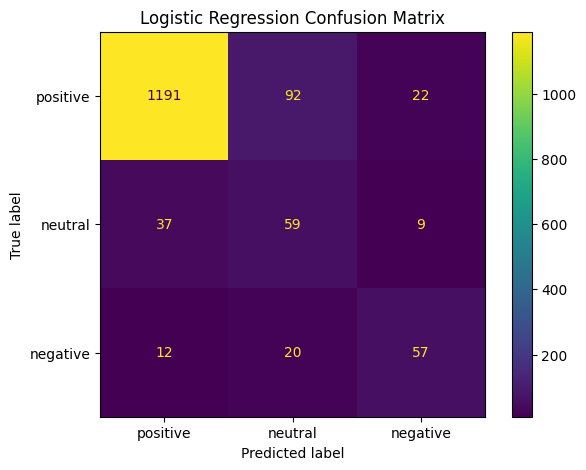

In [22]:
#6.5 Confusion Matrix
labels = [
    "positive",
    "neutral",
    "negative"
]

cm = confusion_matrix(
    y_test,
    y_pred_lr,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(7, 5))

disp.plot(
    ax=ax,
    values_format="d"
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()

# Section 7 —  Model 2: Linear SVM

##  Model 2: Linear Support Vector Machine

Linear Support Vector Machine (Linear SVM) is a widely used algorithm for high-dimensional text classification tasks. It is evaluated using the same TF-IDF features and train-test split as Logistic Regression to ensure a fair comparison.


LINEAR SVM RESULTS
Accuracy: 0.9099
Macro F1-score: 0.6717
Weighted F1-score: 0.8998

CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

    negative     0.7778    0.5506    0.6447        89
     neutral     0.5469    0.3333    0.4142       105
    positive     0.9329    0.9808    0.9563      1305

    accuracy                         0.9099      1499
   macro avg     0.7525    0.6216    0.6717      1499
weighted avg     0.8967    0.9099    0.8998      1499



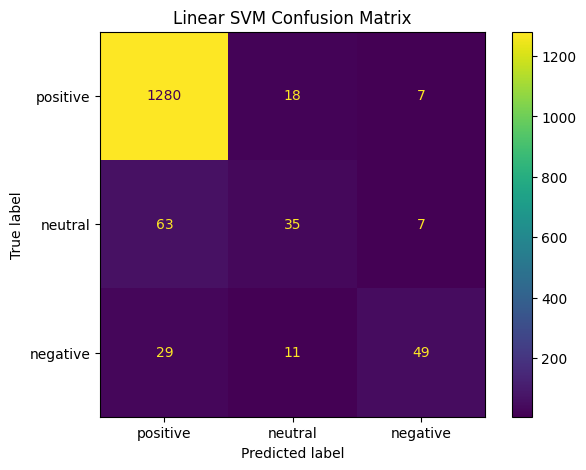

In [23]:
# =========================================================
# MODEL 2: LINEAR SVM
# =========================================================

linear_svm_model = LinearSVC(
    class_weight="balanced",
    random_state=RANDOM_STATE
)

# Train
linear_svm_model.fit(
    X_train_tfidf,
    y_train
)

# Predict
y_pred_svm = linear_svm_model.predict(
    X_test_tfidf
)

# =========================================================
# EVALUATION
# =========================================================

svm_accuracy = accuracy_score(
    y_test,
    y_pred_svm
)

svm_macro_f1 = f1_score(
    y_test,
    y_pred_svm,
    average="macro"
)

svm_weighted_f1 = f1_score(
    y_test,
    y_pred_svm,
    average="weighted"
)

print("=" * 60)
print("LINEAR SVM RESULTS")
print("=" * 60)

print(f"Accuracy: {svm_accuracy:.4f}")
print(f"Macro F1-score: {svm_macro_f1:.4f}")
print(f"Weighted F1-score: {svm_weighted_f1:.4f}")

print("\nCLASSIFICATION REPORT")
print("-" * 60)

print(
    classification_report(
        y_test,
        y_pred_svm,
        digits=4
    )
)

# =========================================================
# CONFUSION MATRIX
# =========================================================

labels = ["positive", "neutral", "negative"]

cm = confusion_matrix(
    y_test,
    y_pred_svm,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(7, 5))

disp.plot(
    ax=ax,
    values_format="d"
)

plt.title("Linear SVM Confusion Matrix")

plt.show()

# Section 8 — Create Validation Split for Transformer Development

## Training and Validation Split for Transformer Development

To ensure unbiased final evaluation, the original 20% test set is kept completely untouched. The existing training data is further divided into training and validation sets. The validation set is used for monitoring model performance and making model development decisions, while the test set is reserved exclusively for final evaluation.


In [24]:
# =========================================================
# CREATE TRAIN / VALIDATION SPLIT
# =========================================================

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.125,  # 12.5% of 80% = 10% of total dataset
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("=" * 60)
print("FINAL DATA SPLIT")
print("=" * 60)

print(f"Training samples:   {len(X_train_final)}")
print(f"Validation samples: {len(X_val)}")
print(f"Testing samples:    {len(X_test)}")

print("\nTraining distribution:")
print(y_train_final.value_counts(normalize=True).mul(100).round(2))

print("\nValidation distribution:")
print(y_val.value_counts(normalize=True).mul(100).round(2))

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

FINAL DATA SPLIT
Training samples:   5245
Validation samples: 750
Testing samples:    1499

Training distribution:
sentiment_label
positive    87.05
neutral      7.02
negative     5.93
Name: proportion, dtype: float64

Validation distribution:
sentiment_label
positive    87.07
neutral      7.07
negative     5.87
Name: proportion, dtype: float64

Testing distribution:
sentiment_label
positive    87.06
neutral      7.00
negative     5.94
Name: proportion, dtype: float64


# Section 9 — Prepare DistilBERT for Sentiment Classification

In [14]:
#9.1 Install dependencies
!pip install -q transformers datasets accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.0 MB/s eta 0:00:00


In [1]:
#9.2 Import required libraries
import torch
import numpy as np

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

from datasets import Dataset

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [4]:
#9.3 Define model and label mappings
MODEL_NAME = "distilbert-base-uncased"

LABEL2ID = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

ID2LABEL = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

print("Model:", MODEL_NAME)
print("Label mapping:", LABEL2ID)

Model: distilbert-base-uncased
Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}


In [25]:
#9.4 Convert Pandas data to Hugging Face Datasets
train_df = pd.DataFrame({
    "text": X_train_final.values,
    "label": y_train_final.map(LABEL2ID).values
})

val_df = pd.DataFrame({
    "text": X_val.values,
    "label": y_val.map(LABEL2ID).values
})

test_df = pd.DataFrame({
    "text": X_test.values,
    "label": y_test.map(LABEL2ID).values
})

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())

Train shape: (5245, 2)
Validation shape: (750, 2)
Test shape: (1499, 2)


,text,label
0,"Filming made Easy. This tripod is sturdy, ligh...",2
1,I love this thing!. I was slow to warm up to t...,2
2,Beautiful and smells great. Love it!,2
3,"Study, accessible, and easy to operate! Highly...",2
4,I would recommend. Good value for a good price,2


In [26]:
train_dataset = Dataset.from_pandas(
    train_df,
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_df,
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df,
    preserve_index=False
)

print(train_dataset)
print(val_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 5245
})
Dataset({
    features: ['text', 'label'],
    num_rows: 750
})
Dataset({
    features: ['text', 'label'],
    num_rows: 1499
})


In [27]:
#9.5 Load DistilBERT Tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("Tokenizer loaded successfully.")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer loaded successfully.


In [28]:
#9.6 Tokenize datasets
MAX_LENGTH = 256

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )


train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True
)

val_tokenized = val_dataset.map(
    tokenize_function,
    batched=True
)

test_tokenized = test_dataset.map(
    tokenize_function,
    batched=True
)

print("Tokenization completed.")

print(train_tokenized)

Map:   0%|          | 0/5245 [00:00<?, ? examples/s]

Map:   0%|          | 0/750 [00:00<?, ? examples/s]

Map:   0%|          | 0/1499 [00:00<?, ? examples/s]

Tokenization completed.
Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 5245
})


In [29]:
#9.7 Prepare dynamic padding
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

print("Dynamic padding configured.")

Dynamic padding configured.


# Section 10 — Define Evaluation Metrics and Configure DistilBERT Training

In [30]:
#10.1 Define evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    f1_score
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1
    }

In [31]:
#10.2 Initialize DistilBERT model
NUM_LABELS = 3

distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID
)

print("DistilBERT model initialized successfully.")

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT model initialized successfully.


In [32]:
#10.3 Configure training arguments
training_args = TrainingArguments(
    output_dir="./distilbert_sentiment_results",

    num_train_epochs=5,

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    logging_strategy="steps",
    logging_steps=50,

    save_total_limit=2,

    report_to="none",

    fp16=torch.cuda.is_available(),

    seed=RANDOM_STATE
)

print("Training configuration completed.")

Training configuration completed.


In [33]:
#10.4 Configure Early Stopping
early_stopping = EarlyStoppingCallback(
    early_stopping_patience=2
)

In [34]:
trainer = Trainer(
    model=distilbert_model,
    args=training_args,

    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,

    processing_class=tokenizer,
    data_collator=data_collator,

    compute_metrics=compute_metrics,

    callbacks=[early_stopping]
)

print("Trainer initialized successfully.")

Trainer initialized successfully.


# Section 11 — Train Baseline DistilBERT & Evaluate Validation Performance

In [35]:
#11.1 Train DistilBERT
# =========================================================
# TRAIN BASELINE DISTILBERT
# =========================================================

print("Starting DistilBERT training...")

train_result = trainer.train()

print("\nTraining completed successfully.")

Starting DistilBERT training...


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.336114,0.262521,0.909333,0.682206,0.614045,0.596804
2,0.244973,0.219876,0.917333,0.762438,0.693499,0.721617
3,0.140089,0.258918,0.906667,0.703258,0.680430,0.691286
4,0.086289,0.304840,0.921333,0.771117,0.698890,0.731028
5,0.041439,0.313162,0.910667,0.734347,0.687741,0.708507


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training completed successfully.


In [36]:
#11.2 Evaluate on Validation Set
# =========================================================
# VALIDATION EVALUATION
# =========================================================

validation_results = trainer.evaluate(
    eval_dataset=val_tokenized
)

print("=" * 60)
print("DISTILBERT VALIDATION RESULTS")
print("=" * 60)

for metric, value in validation_results.items():
    print(f"{metric}: {value:.4f}" if isinstance(value, float) else f"{metric}: {value}")

Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1
0.041439,0.304840,5,0.921333,0.771117,0.698890,0.731028


DISTILBERT VALIDATION RESULTS
eval_loss: 0.3048
eval_accuracy: 0.9213
eval_macro_precision: 0.7711
eval_macro_recall: 0.6989
eval_macro_f1: 0.7310


In [37]:
#11.3 Generate Detailed Classification Report
# =========================================================
# VALIDATION PREDICTIONS
# =========================================================

val_predictions = trainer.predict(
    val_tokenized
)

val_logits = val_predictions.predictions

val_pred_ids = np.argmax(
    val_logits,
    axis=1
)

val_true_ids = val_predictions.label_ids

val_pred_labels = [
    ID2LABEL[label_id]
    for label_id in val_pred_ids
]

val_true_labels = [
    ID2LABEL[label_id]
    for label_id in val_true_ids
]

print(
    classification_report(
        val_true_labels,
        val_pred_labels,
        labels=["negative", "neutral", "positive"],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    negative     0.8611    0.7045    0.7750        44
     neutral     0.5000    0.4151    0.4536        53
    positive     0.9522    0.9770    0.9645       653

    accuracy                         0.9213       750
   macro avg     0.7711    0.6989    0.7310       750
weighted avg     0.9149    0.9213    0.9173       750



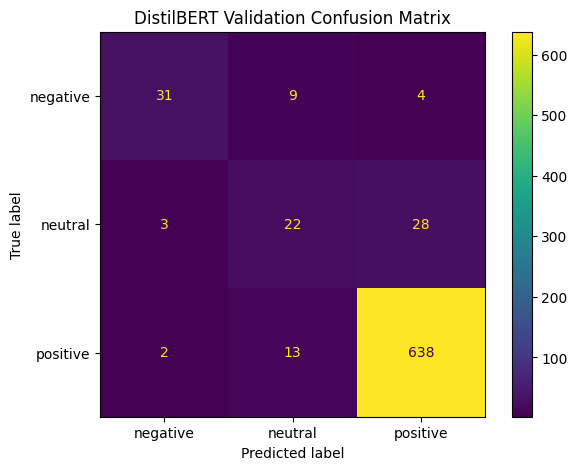

In [38]:
#11.4 Validation Confusion Matrix
# =========================================================
# VALIDATION CONFUSION MATRIX
# =========================================================

labels = ["negative", "neutral", "positive"]

cm = confusion_matrix(
    val_true_labels,
    val_pred_labels,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(7, 5))

disp.plot(
    ax=ax,
    values_format="d"
)

plt.title(
    "DistilBERT Validation Confusion Matrix"
)

plt.show()

# Section 12 — DistilBERT with Class-Weighted Loss

Our dataset is highly imbalanced, so we'll now train a second DistilBERT experiment using weighted CrossEntropyLoss.

In [39]:
#12.1 Calculate class weights
from sklearn.utils.class_weight import compute_class_weight

# Class IDs in the correct order
class_ids = np.array([0, 1, 2])

# Calculate balanced class weights from training labels only
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=class_ids,
    y=y_train_final.map(LABEL2ID).values
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float
)

print("Class weights:")

for class_id, weight in enumerate(class_weights):
    print(
        f"{ID2LABEL[class_id]}: "
        f"{weight.item():.4f}"
    )

Class weights:
negative: 5.6217
neutral: 4.7509
positive: 0.3829


In [40]:
#12.2 Create a Custom Weighted Trainer
import torch.nn as nn
from transformers import Trainer

class WeightedTrainer(Trainer):

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None
    ):
        labels = inputs.pop("labels")

        outputs = model(**inputs)

        logits = outputs.get("logits")

        loss_function = nn.CrossEntropyLoss(
            weight=class_weights.to(logits.device)
        )

        loss = loss_function(
            logits,
            labels
        )

        return (
            (loss, outputs)
            if return_outputs
            else loss
        )

In [41]:
#12.3 Initialize a Fresh DistilBERT Model
weighted_distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID
)

print("Fresh weighted DistilBERT model initialized.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fresh weighted DistilBERT model initialized.


In [42]:
#12.4 Configure Training Arguments
weighted_training_args = TrainingArguments(
    output_dir="./weighted_distilbert_results",

    num_train_epochs=5,

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    logging_strategy="steps",
    logging_steps=50,

    save_total_limit=2,

    report_to="none",

    fp16=torch.cuda.is_available(),

    seed=RANDOM_STATE
)

In [46]:
#12.5 Initialize Weighted Trainer
weighted_trainer = WeightedTrainer(
    model=weighted_distilbert_model,
    args=weighted_training_args,

    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,

    processing_class=tokenizer,
    data_collator=data_collator,

    compute_metrics=compute_metrics,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

print("Weighted Trainer initialized successfully.")

Weighted Trainer initialized successfully.


In [47]:
#12.6 Train Weighted DistilBERT
print("Starting Weighted DistilBERT training...")

weighted_train_result = weighted_trainer.train()

print("\nWeighted DistilBERT training completed.")

Starting Weighted DistilBERT training...


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.769709,0.618898,0.904000,0.719118,0.746203,0.731812
2,0.551051,0.551487,0.849333,0.702968,0.768278,0.698662
3,0.353917,0.821578,0.909333,0.736274,0.745672,0.739695
4,0.331156,0.966959,0.916000,0.768283,0.768767,0.764313
5,0.095043,1.084757,0.917333,0.768765,0.756433,0.758782


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Weighted DistilBERT training completed.


In [48]:
#12.7 Evaluate on Validation Set
weighted_validation_results = weighted_trainer.evaluate(
    eval_dataset=val_tokenized
)

print("=" * 60)
print("WEIGHTED DISTILBERT VALIDATION RESULTS")
print("=" * 60)

for metric, value in weighted_validation_results.items():
    print(
        f"{metric}: {value:.4f}"
        if isinstance(value, float)
        else f"{metric}: {value}"
    )

Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1
0.095043,0.966959,5,0.916000,0.768283,0.768767,0.764313


WEIGHTED DISTILBERT VALIDATION RESULTS
eval_loss: 0.9670
eval_accuracy: 0.9160
eval_macro_precision: 0.7683
eval_macro_recall: 0.7688
eval_macro_f1: 0.7643


In [49]:
#12.8 Detailed Classification Report
weighted_val_predictions = weighted_trainer.predict(
    val_tokenized
)

weighted_val_logits = weighted_val_predictions.predictions

weighted_val_pred_ids = np.argmax(
    weighted_val_logits,
    axis=1
)

weighted_val_true_ids = weighted_val_predictions.label_ids

weighted_val_pred_labels = [
    ID2LABEL[label_id]
    for label_id in weighted_val_pred_ids
]

weighted_val_true_labels = [
    ID2LABEL[label_id]
    for label_id in weighted_val_true_ids
]

print(
    classification_report(
        weighted_val_true_labels,
        weighted_val_pred_labels,
        labels=["negative", "neutral", "positive"],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    negative     0.8684    0.7500    0.8049        44
     neutral     0.4706    0.6038    0.5289        53
    positive     0.9658    0.9525    0.9591       653

    accuracy                         0.9160       750
   macro avg     0.7683    0.7688    0.7643       750
weighted avg     0.9251    0.9160    0.9197       750



#Current Model Ranking

Based on validation Macro F1:

1. Weighted DistilBERT   0.7643
2. Baseline DistilBERT   0.7310
3. Linear SVM             0.6724
4. Logistic Regression    0.6719

# Section 13 — Adjustable Decision Threshold for Weighted DistilBERT

In [50]:
#13.1 Get validation probabilities
# =========================================================
# GET VALIDATION PROBABILITIES
# =========================================================

from scipy.special import softmax

weighted_val_predictions = weighted_trainer.predict(
    val_tokenized
)

weighted_val_logits = weighted_val_predictions.predictions
weighted_val_true_ids = weighted_val_predictions.label_ids

weighted_val_probs = softmax(
    weighted_val_logits,
    axis=1
)

print("Probability matrix shape:", weighted_val_probs.shape)
print("Classes:", ID2LABEL)

Probability matrix shape: (750, 3)
Classes: {0: 'negative', 1: 'neutral', 2: 'positive'}


In [51]:
#13.2 Create adjustable threshold prediction function
# =========================================================
# ADJUSTABLE THRESHOLD PREDICTION
# =========================================================

def predict_with_thresholds(
    probabilities,
    thresholds=(1.0, 1.0, 1.0)
):
    """
    Apply class-specific decision thresholds.

    thresholds:
        (negative_threshold,
         neutral_threshold,
         positive_threshold)
    """

    thresholds = np.array(thresholds)

    # Adjust probabilities by thresholds
    adjusted_scores = probabilities / thresholds

    # Select class with highest adjusted score
    predictions = np.argmax(
        adjusted_scores,
        axis=1
    )

    return predictions

In [52]:
#13.3 Verify the default behavior
# Default thresholds
default_predictions = predict_with_thresholds(
    weighted_val_probs,
    thresholds=(1.0, 1.0, 1.0)
)

default_macro_f1 = f1_score(
    weighted_val_true_ids,
    default_predictions,
    average="macro"
)

print(
    f"Default Macro F1: {default_macro_f1:.4f}"
)

Default Macro F1: 0.7643


In [53]:
#13.4 Automatically search for better thresholds
# =========================================================
# THRESHOLD SEARCH
# =========================================================

threshold_values = np.arange(
    0.70,
    1.31,
    0.05
)

best_f1 = 0
best_thresholds = None

for negative_threshold in threshold_values:

    for neutral_threshold in threshold_values:

        for positive_threshold in threshold_values:

            thresholds = (
                negative_threshold,
                neutral_threshold,
                positive_threshold
            )

            predictions = predict_with_thresholds(
                weighted_val_probs,
                thresholds
            )

            macro_f1 = f1_score(
                weighted_val_true_ids,
                predictions,
                average="macro"
            )

            if macro_f1 > best_f1:

                best_f1 = macro_f1
                best_thresholds = thresholds


print("=" * 60)
print("BEST THRESHOLD CONFIGURATION")
print("=" * 60)

print(
    f"Negative threshold: {best_thresholds[0]:.2f}"
)

print(
    f"Neutral threshold:  {best_thresholds[1]:.2f}"
)

print(
    f"Positive threshold: {best_thresholds[2]:.2f}"
)

print(
    f"Validation Macro F1: {best_f1:.4f}"
)

BEST THRESHOLD CONFIGURATION
Negative threshold: 0.70
Neutral threshold:  1.15
Positive threshold: 0.70
Validation Macro F1: 0.7670


In [54]:
#13.5 Compare default vs optimized threshold
print("=" * 60)
print("THRESHOLD OPTIMIZATION COMPARISON")
print("=" * 60)

print(
    f"Default Macro F1:    {default_macro_f1:.4f}"
)

print(
    f"Optimized Macro F1:  {best_f1:.4f}"
)

print(
    f"Improvement:         "
    f"{best_f1 - default_macro_f1:+.4f}"
)

THRESHOLD OPTIMIZATION COMPARISON
Default Macro F1:    0.7643
Optimized Macro F1:  0.7670
Improvement:         +0.0027


In [55]:
#13.6 Detailed report using optimized thresholds
# =========================================================
# OPTIMIZED VALIDATION REPORT
# =========================================================

optimized_val_predictions = predict_with_thresholds(
    weighted_val_probs,
    best_thresholds
)

print(
    classification_report(
        weighted_val_true_ids,
        optimized_val_predictions,
        target_names=[
            "negative",
            "neutral",
            "positive"
        ],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    negative     0.8684    0.7500    0.8049        44
     neutral     0.4921    0.5849    0.5345        53
    positive     0.9646    0.9587    0.9616       653

    accuracy                         0.9200       750
   macro avg     0.7750    0.7645    0.7670       750
weighted avg     0.9255    0.9200    0.9222       750



In [56]:
#13.7 Save the selected thresholds
FINAL_THRESHOLDS = {
    "negative": float(best_thresholds[0]),
    "neutral": float(best_thresholds[1]),
    "positive": float(best_thresholds[2])
}

print("Final threshold configuration:")
print(FINAL_THRESHOLDS)

Final threshold configuration:
{'negative': 0.7, 'neutral': 1.1500000000000004, 'positive': 0.7}


# Section 14 — Final Test Evaluation

In [57]:
# =========================================================
# FINAL TEST PREDICTIONS
# =========================================================

test_predictions = weighted_trainer.predict(
    test_tokenized
)

test_logits = test_predictions.predictions
test_true_ids = test_predictions.label_ids

test_probs = softmax(
    test_logits,
    axis=1
)

print("Test probability matrix:", test_probs.shape)

Test probability matrix: (1499, 3)


In [58]:
# =========================================================
# APPLY FROZEN FINAL THRESHOLDS
# =========================================================

test_thresholds = (
    FINAL_THRESHOLDS["negative"],
    FINAL_THRESHOLDS["neutral"],
    FINAL_THRESHOLDS["positive"]
)

test_pred_ids = predict_with_thresholds(
    test_probs,
    test_thresholds
)

In [59]:
# =========================================================
# FINAL TEST CLASSIFICATION REPORT
# =========================================================

print("=" * 60)
print("FINAL TEST RESULTS — WEIGHTED DISTILBERT")
print("=" * 60)

print(
    classification_report(
        test_true_ids,
        test_pred_ids,
        target_names=[
            "negative",
            "neutral",
            "positive"
        ],
        digits=4,
        zero_division=0
    )
)

FINAL TEST RESULTS — WEIGHTED DISTILBERT
              precision    recall  f1-score   support

    negative     0.8630    0.7079    0.7778        89
     neutral     0.4286    0.5429    0.4790       105
    positive     0.9644    0.9556    0.9600      1305

    accuracy                         0.9119      1499
   macro avg     0.7520    0.7354    0.7389      1499
weighted avg     0.9209    0.9119    0.9155      1499



In [60]:
# =========================================================
# FINAL TEST METRICS
# =========================================================

final_accuracy = accuracy_score(
    test_true_ids,
    test_pred_ids
)

final_macro_precision = precision_score(
    test_true_ids,
    test_pred_ids,
    average="macro",
    zero_division=0
)

final_macro_recall = recall_score(
    test_true_ids,
    test_pred_ids,
    average="macro",
    zero_division=0
)

final_macro_f1 = f1_score(
    test_true_ids,
    test_pred_ids,
    average="macro",
    zero_division=0
)

final_weighted_f1 = f1_score(
    test_true_ids,
    test_pred_ids,
    average="weighted",
    zero_division=0
)

print("=" * 60)
print("FINAL TEST METRICS")
print("=" * 60)

print(f"Accuracy:          {final_accuracy:.4f}")
print(f"Macro Precision:   {final_macro_precision:.4f}")
print(f"Macro Recall:      {final_macro_recall:.4f}")
print(f"Macro F1:          {final_macro_f1:.4f}")
print(f"Weighted F1:       {final_weighted_f1:.4f}")

FINAL TEST METRICS
Accuracy:          0.9119
Macro Precision:   0.7520
Macro Recall:      0.7354
Macro F1:          0.7389
Weighted F1:       0.9155


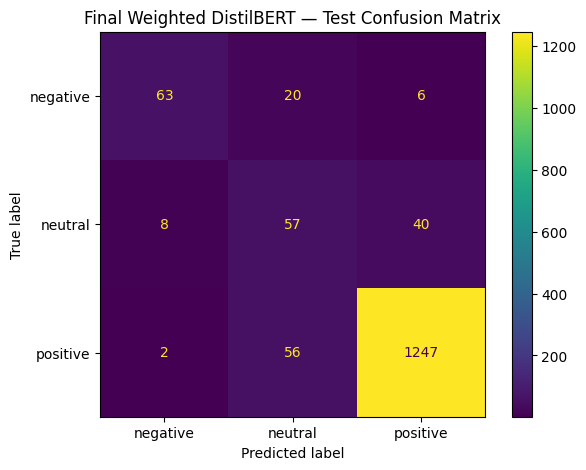

In [61]:
# =========================================================
# FINAL TEST CONFUSION MATRIX
# =========================================================

labels = ["negative", "neutral", "positive"]

cm = confusion_matrix(
    test_true_ids,
    test_pred_ids,
    labels=[0, 1, 2]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(7, 5))

disp.plot(
    ax=ax,
    values_format="d"
)

plt.title(
    "Final Weighted DistilBERT — Test Confusion Matrix"
)

plt.show()

# Section 15 — Model Comparison

###15.1 Logistic Regression — Test Evaluation

In [62]:

# =========================================================
# LOGISTIC REGRESSION — FINAL TEST EVALUATION
# =========================================================

lr_test_pred = logistic_model.predict(
    X_test_tfidf
)

lr_test_accuracy = accuracy_score(
    y_test,
    lr_test_pred
)

lr_test_macro_f1 = f1_score(
    y_test,
    lr_test_pred,
    average="macro"
)

lr_test_weighted_f1 = f1_score(
    y_test,
    lr_test_pred,
    average="weighted"
)

print("=" * 60)
print("LOGISTIC REGRESSION — TEST")
print("=" * 60)

print(f"Accuracy: {lr_test_accuracy:.4f}")
print(f"Macro F1: {lr_test_macro_f1:.4f}")
print(f"Weighted F1: {lr_test_weighted_f1:.4f}")

print(
    classification_report(
        y_test,
        lr_test_pred,
        digits=4,
        zero_division=0
    )
)

LOGISTIC REGRESSION — TEST
Accuracy: 0.8719
Macro F1: 0.6692
Weighted F1: 0.8830
              precision    recall  f1-score   support

    negative     0.6477    0.6404    0.6441        89
     neutral     0.3450    0.5619    0.4275       105
    positive     0.9605    0.9126    0.9360      1305

    accuracy                         0.8719      1499
   macro avg     0.6511    0.7050    0.6692      1499
weighted avg     0.8988    0.8719    0.8830      1499



##15.2 Linear SVM — Test Evaluation

In [63]:
# =========================================================
# LINEAR SVM — FINAL TEST EVALUATION
# =========================================================

svm_test_pred = linear_svm_model.predict(
    X_test_tfidf
)

svm_test_accuracy = accuracy_score(
    y_test,
    svm_test_pred
)

svm_test_macro_f1 = f1_score(
    y_test,
    svm_test_pred,
    average="macro"
)

svm_test_weighted_f1 = f1_score(
    y_test,
    svm_test_pred,
    average="weighted"
)

print("=" * 60)
print("LINEAR SVM — TEST")
print("=" * 60)

print(f"Accuracy: {svm_test_accuracy:.4f}")
print(f"Macro F1: {svm_test_macro_f1:.4f}")
print(f"Weighted F1: {svm_test_weighted_f1:.4f}")

print(
    classification_report(
        y_test,
        svm_test_pred,
        digits=4,
        zero_division=0
    )
)

LINEAR SVM — TEST
Accuracy: 0.9099
Macro F1: 0.6717
Weighted F1: 0.8998
              precision    recall  f1-score   support

    negative     0.7778    0.5506    0.6447        89
     neutral     0.5469    0.3333    0.4142       105
    positive     0.9329    0.9808    0.9563      1305

    accuracy                         0.9099      1499
   macro avg     0.7525    0.6216    0.6717      1499
weighted avg     0.8967    0.9099    0.8998      1499



##15.3 Build the Final Comparison Table

In [64]:
# =========================================================
# FINAL MODEL COMPARISON
# =========================================================

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "Weighted DistilBERT"
    ],
    "Accuracy": [
        lr_test_accuracy,
        svm_test_accuracy,
        final_accuracy
    ],
    "Macro F1": [
        lr_test_macro_f1,
        svm_test_macro_f1,
        final_macro_f1
    ],
    "Weighted F1": [
        lr_test_weighted_f1,
        svm_test_weighted_f1,
        final_weighted_f1
    ]
})

comparison = comparison.sort_values(
    "Macro F1",
    ascending=False
).reset_index(drop=True)

display(
    comparison.style.format({
        "Accuracy": "{:.4f}",
        "Macro F1": "{:.4f}",
        "Weighted F1": "{:.4f}"
    })
)

,Model,Accuracy,Macro F1,Weighted F1
0,Weighted DistilBERT,0.9119,0.7389,0.9155
1,Linear SVM,0.9099,0.6717,0.8998
2,Logistic Regression,0.8719,0.6692,0.8830


#Section 16 — Final Model Selection Statement


## Final Model Selection

Three sentiment classification approaches were evaluated: TF-IDF with Logistic Regression, TF-IDF with Linear SVM, and a class-weighted DistilBERT transformer model. Because the sentiment dataset was highly imbalanced, with positive reviews representing 87.06% of the dataset, Macro F1-score was selected as the primary model-selection metric.

On the same untouched 20% test set, the class-weighted DistilBERT model achieved the best overall performance, with an accuracy of 91.19%, Macro F1-score of 73.89%, and Weighted F1-score of 91.55%. Linear SVM achieved a Macro F1-score of 67.17%, while Logistic Regression achieved 66.92%.

The class-weighted DistilBERT model was therefore selected as the final sentiment classification model. Class weighting improved the model's ability to identify minority sentiment classes, particularly negative and neutral reviews. In addition, class-specific decision thresholds were implemented and optimized using the validation set, providing an adjustable prediction mechanism without modifying the trained model parameters.

The final selected model is therefore the class-weighted DistilBERT classifier with configurable decision thresholds.


In [65]:
#16.1 Define the final model directory
# =========================================================
# FINAL MODEL DIRECTORY
# =========================================================

import os
import json

FINAL_MODEL_DIR = "./final_sentiment_model"

os.makedirs(FINAL_MODEL_DIR, exist_ok=True)

print("Saving final model to:", FINAL_MODEL_DIR)

Saving final model to: ./final_sentiment_model


In [66]:
#16.2 Save the trained DistilBERT model
# =========================================================
# SAVE FINAL DISTILBERT MODEL
# =========================================================

weighted_trainer.save_model(FINAL_MODEL_DIR)

print("Final DistilBERT model saved.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Final DistilBERT model saved.


In [67]:
#16.3 Save the tokenizer
# =========================================================
# SAVE TOKENIZER
# =========================================================

tokenizer.save_pretrained(FINAL_MODEL_DIR)

print("Tokenizer saved.")

Tokenizer saved.


In [68]:
#16.4 Save label mappings
# =========================================================
# SAVE LABEL MAPPINGS
# =========================================================

label_mapping = {
    "label2id": LABEL2ID,
    "id2label": {
        str(k): v
        for k, v in ID2LABEL.items()
    }
}

with open(
    os.path.join(FINAL_MODEL_DIR, "label_mapping.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        label_mapping,
        f,
        indent=4
    )

print("Label mapping saved.")

Label mapping saved.


In [69]:
#16.5 Save the optimized thresholds
# =========================================================
# SAVE FINAL THRESHOLDS
# =========================================================

FINAL_THRESHOLDS = {
    "negative": 0.70,
    "neutral": 1.15,
    "positive": 0.70
}

with open(
    os.path.join(FINAL_MODEL_DIR, "thresholds.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        FINAL_THRESHOLDS,
        f,
        indent=4
    )

print("Threshold configuration saved.")
print(FINAL_THRESHOLDS)

Threshold configuration saved.
{'negative': 0.7, 'neutral': 1.15, 'positive': 0.7}


In [71]:
#16.6 Save model metadata
# =========================================================
# SAVE MODEL METADATA
# =========================================================

metadata = {
    "model_name": MODEL_NAME,
    "model_type": "DistilBERT",
    "task": "3-class sentiment classification",
    "classes": [
        "negative",
        "neutral",
        "positive"
    ],
    "class_weighted": True,
    "threshold_optimized": True,
    "threshold_metric": "validation_macro_f1",
    "validation_macro_f1": float(best_f1),
    "test_accuracy": float(final_accuracy),
    "test_macro_f1": float(final_macro_f1),
    "test_weighted_f1": float(final_weighted_f1)
}

with open(
    os.path.join(FINAL_MODEL_DIR, "metadata.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metadata,
        f,
        indent=4
    )

print("Metadata saved.")

Metadata saved.


In [73]:
#16.7 Verify the saved files
# =========================================================
# VERIFY FINAL MODEL PACKAGE
# =========================================================

print("=" * 60)
print("FINAL MODEL PACKAGE")
print("=" * 60)

for root, dirs, files in os.walk(FINAL_MODEL_DIR):
    level = root.replace(FINAL_MODEL_DIR, "").count(os.sep)
    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    {file}")

FINAL MODEL PACKAGE
final_sentiment_model/
    tokenizer_config.json
    metadata.json
    thresholds.json
    model.safetensors
    config.json
    label_mapping.json
    training_args.bin
    tokenizer.json


In [74]:
#16.8 Test that the model can actually be reloaded
# =========================================================
# RELOAD TEST
# =========================================================

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

loaded_tokenizer = AutoTokenizer.from_pretrained(
    FINAL_MODEL_DIR
)

loaded_model = AutoModelForSequenceClassification.from_pretrained(
    FINAL_MODEL_DIR
)

loaded_model.eval()

print("Model and tokenizer reloaded successfully.")
print("Labels:", loaded_model.config.id2label)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model and tokenizer reloaded successfully.
Labels: {0: 'negative', 1: 'neutral', 2: 'positive'}


In [83]:
#16.9 Test one real review
# =========================================================
# FINAL MODEL INFERENCE TEST
# =========================================================

sample_text = X_test.iloc[2]

inputs = loaded_tokenizer(
    sample_text,
    return_tensors="pt",
    truncation=True,
    max_length=MAX_LENGTH
)

with torch.no_grad():
    outputs = loaded_model(**inputs)

sample_probs = torch.softmax(
    outputs.logits,
    dim=1
).numpy()

sample_prediction = predict_with_thresholds(
    sample_probs,
    (
        FINAL_THRESHOLDS["negative"],
        FINAL_THRESHOLDS["neutral"],
        FINAL_THRESHOLDS["positive"]
    )
)[0]

print("=" * 60)
print("FINAL MODEL INFERENCE TEST")
print("=" * 60)

print("Review:")
print(sample_text)

print("\nProbabilities:")

for i, label in ID2LABEL.items():
    print(
        f"{label}: {sample_probs[0][i]:.4f}"
    )

print(
    "\nPredicted sentiment:",
    ID2LABEL[sample_prediction]
)

print(
    "Actual sentiment:",
    y_test.iloc[2]
)

FINAL MODEL INFERENCE TEST
Review:
Nice sunglasses. I’m really happy with these sunglasses. They look great, feel comfortable, and seem to be made with good quality materials. They fit well and provide good coverage from the sun without feeling heavy. The style is nice, and they’ve held up well with regular use. Overall, a great pair of sunglasses for the price, and I would recommend them to others.

Probabilities:
negative: 0.0020
neutral: 0.0017
positive: 0.9963

Predicted sentiment: positive
Actual sentiment: positive


#Section 17 — Export/Download the Final Model Package

In [84]:
#17.1 Create the ZIP
# =========================================================
# EXPORT FINAL MODEL PACKAGE
# =========================================================

import shutil
import os

MODEL_DIR = "./final_sentiment_model"
ZIP_PATH = "./final_sentiment_model"

if not os.path.exists(MODEL_DIR):
    raise FileNotFoundError(
        f"Model directory not found: {MODEL_DIR}"
    )

zip_file = shutil.make_archive(
    ZIP_PATH,
    "zip",
    MODEL_DIR
)

print("=" * 60)
print("FINAL MODEL PACKAGE EXPORTED")
print("=" * 60)
print(f"ZIP file: {zip_file}")
print(f"Size: {os.path.getsize(zip_file) / (1024**2):.2f} MB")

FINAL MODEL PACKAGE EXPORTED
ZIP file: /content/final_sentiment_model.zip
Size: 235.75 MB


In [85]:
#17.2 Verify the ZIP contents
# =========================================================
# VERIFY ZIP CONTENTS
# =========================================================

import zipfile

with zipfile.ZipFile(
    "final_sentiment_model.zip",
    "r"
) as zip_ref:

    files = zip_ref.namelist()

print("=" * 60)
print("ZIP CONTENTS")
print("=" * 60)

for file in files:
    print(file)

ZIP CONTENTS
tokenizer_config.json
metadata.json
thresholds.json
model.safetensors
config.json
label_mapping.json
training_args.bin
tokenizer.json


In [86]:
#17.3 Download the ZIP
from google.colab import files

files.download(
    "final_sentiment_model.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Section 18 — Build a Reusable Sentiment Inference Pipeline

In [93]:
#18.1 Create a reusable SentimentPredictor class
# =========================================================
# FINAL REUSABLE SENTIMENT INFERENCE PIPELINE
# =========================================================

import os
import json
import numpy as np
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)


class SentimentPredictor:

    def __init__(
        self,
        model_dir="./final_sentiment_model",
        max_length=256
    ):
        self.model_dir = model_dir
        self.max_length = max_length

        self.device = torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )

        self.tokenizer = AutoTokenizer.from_pretrained(
            model_dir
        )

        self.model = (
            AutoModelForSequenceClassification
            .from_pretrained(model_dir)
            .to(self.device)
        )

        self.model.eval()

        with open(
            os.path.join(model_dir, "thresholds.json"),
            "r",
            encoding="utf-8"
        ) as f:
            self.thresholds = json.load(f)

        with open(
            os.path.join(model_dir, "label_mapping.json"),
            "r",
            encoding="utf-8"
        ) as f:
            mappings = json.load(f)

        self.id2label = {
            int(k): v
            for k, v in mappings["id2label"].items()
        }

    def _predict_probabilities(self, texts):

        inputs = self.tokenizer(
            texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=self.max_length
        )

        inputs = {
            key: value.to(self.device)
            for key, value in inputs.items()
        }

        with torch.no_grad():
            outputs = self.model(**inputs)

        return torch.softmax(
            outputs.logits,
            dim=1
        ).cpu().numpy()

    def _apply_thresholds(self, probabilities):

        threshold_values = np.array([
            self.thresholds["negative"],
            self.thresholds["neutral"],
            self.thresholds["positive"]
        ])

        adjusted_scores = probabilities / threshold_values

        return np.argmax(
            adjusted_scores,
            axis=1
        )

    def predict(self, text):

        if not isinstance(text, str) or not text.strip():
            raise ValueError(
                "Input text must be a non-empty string."
            )

        probabilities = self._predict_probabilities(
            [text]
        )

        prediction_id = self._apply_thresholds(
            probabilities
        )[0]

        return {
            "sentiment": self.id2label[
                int(prediction_id)
            ],
            "probabilities": {
                self.id2label[i]: round(
                    float(probabilities[0][i]),
                    4
                )
                for i in range(
                    probabilities.shape[1]
                )
            }
        }

    def predict_batch(
        self,
        texts,
        batch_size=32
    ):

        if not texts:
            return []

        results = []

        for start in range(
            0,
            len(texts),
            batch_size
        ):

            batch = texts[
                start:start + batch_size
            ]

            probabilities = (
                self._predict_probabilities(batch)
            )

            prediction_ids = (
                self._apply_thresholds(probabilities)
            )

            for probs, prediction_id in zip(
                probabilities,
                prediction_ids
            ):

                results.append({
                    "sentiment": self.id2label[
                        int(prediction_id)
                    ],
                    "probabilities": {
                        self.id2label[i]: round(
                            float(probs[i]),
                            4
                        )
                        for i in range(
                            len(probs)
                        )
                    }
                })

        return results


# =========================================================
# INITIALIZE
# =========================================================

predictor = SentimentPredictor(
    model_dir="./final_sentiment_model"
)

print("Sentiment Predictor Ready!")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Sentiment Predictor Ready!


In [99]:
#18.2 Test all three sentiment types
# =========================================================
# MULTIPLE SENTIMENT TESTS
# =========================================================

test_reviews = [
    "Absolutely amazing product. Great quality and I love it!",

    "not bad",

    "Terrible quality. It stopped working after two days. Very disappointed."
]

for review in test_reviews:

    result = predictor.predict(review)

    print("=" * 60)
    print("Review:")
    print(review)

    print("\nPrediction:")
    print(result["sentiment"])

    print("\nProbabilities:")
    for label, probability in result["probabilities"].items():
        print(f"{label}: {probability:.4f}")

Review:
Absolutely amazing product. Great quality and I love it!

Prediction:
positive

Probabilities:
negative: 0.0028
neutral: 0.0017
positive: 0.9955
Review:
not bad

Prediction:
neutral

Probabilities:
negative: 0.1027
neutral: 0.8311
positive: 0.0663
Review:
Terrible quality. It stopped working after two days. Very disappointed.

Prediction:
negative

Probabilities:
negative: 0.9955
neutral: 0.0017
positive: 0.0028


In [100]:
#18.3 Test batch prediction
reviews = [
    "This product is fantastic. Excellent quality!",
    "It is okay and works as expected.",
    "Very poor quality. Completely disappointed.",
    "I love this product and would buy it again."
]

results = predictor.predict_batch(reviews)

for review, result in zip(reviews, results):
    print("=" * 60)
    print("Review:", review)
    print("Sentiment:", result["sentiment"])
    print("Probabilities:", result["probabilities"])

Review: This product is fantastic. Excellent quality!
Sentiment: positive
Probabilities: {'negative': 0.0027, 'neutral': 0.0016, 'positive': 0.9957}
Review: It is okay and works as expected.
Sentiment: neutral
Probabilities: {'negative': 0.0982, 'neutral': 0.8098, 'positive': 0.092}
Review: Very poor quality. Completely disappointed.
Sentiment: negative
Probabilities: {'negative': 0.9951, 'neutral': 0.0019, 'positive': 0.003}
Review: I love this product and would buy it again.
Sentiment: positive
Probabilities: {'negative': 0.0023, 'neutral': 0.0021, 'positive': 0.9956}
